# Grapevine Immunity Transcriptomics — Python Learning Toolkit

**Based on:** Hádlík M., Baránek M., Baránková K., Kovacova V.  
*"A SOBIR1-associated receptor network shows Rpv12-specific upregulation in grapevine downy mildew resistance"*  
bioRxiv 2025 · [doi:10.1101/2025.11.27.690962](https://doi.org/10.1101/2025.11.27.690962) · [NCBI BioProject PRJNA1358055](https://www.ncbi.nlm.nih.gov/bioproject/PRJNA1358055)

---

This notebook is a **Python learning companion** to the RNA-seq analysis pipeline from the paper above.
It covers QC, normalization, batch correction, differential gene expression, aggregated expression divergence,
and co-transcriptional network analysis — in Python, using **PyDESeq2** and **NetworkX**.

> ⚠️ **Published analysis vs teaching notebook**
> The paper was analysed in **R** using DESeq2 `rlog` transformation (stored in `data_files/Rlogs.csv`),
> which is the gold standard for variance stabilization in RNA-seq.
> This notebook uses PyDESeq2's **VST** (`vst_combat`) as the Python-accessible equivalent for teaching purposes.
> VST and rlog are conceptually analogous (both variance-stabilize; both followed by ComBat batch correction)
> but will produce numerically different values. For reproducing published figures exactly, use the R scripts
> in `02_Normalization_and_DGEA/`, `03_AED/`, and `06_PCNWA/`.

**Learning goals:**
1. Understand why and how batch effects are detected and corrected in RNA-seq
2. Apply size-factor normalization and VST in Python (PyDESeq2); compare all 8 normalization strategies
3. Perform differential expression analysis with PyDESeq2 and with a GLM on VST+ComBat values
4. Implement a custom permutation-based divergence metric (AED)
5. Build and analyse co-transcriptional networks with NetworkX

---

**Data files required** (paths are relative to the project root `plant_immunity_Vitis/`):
- `01_QC_and_Filtering/Batch_effects/reads_overview.csv` — mapping quality metrics per library
- `data_files/RawCounts.csv` — raw gene counts (26 169 genes × 36 samples)
- `data_files/SizeFactorNorm_ComBat_36samples.csv` — size-factor + log2 + ComBat values (pre-computed in R)
- `data_files/Patterns_01_DUE.csv` — DE pattern codes per gene (3 553 DE genes)
- `data_files/Vitis_gene_immunity_class.csv` — PTI / ETI / shared gene classification
- `data_files/node1_node2_ConfidenceScore_stringDB.csv` — STRING-db network edge list

VST-transformed + ComBat values (`vst_combat`) are computed on-the-fly by PyDESeq2 in Section 2.


## Table of Contents

1. [Biological Background](#biology)
2. [Setup: packages and data loading](#setup)
3. [Section 1 — Batch Effect Detection from Read Mapping Statistics](#sec1)
4. [Section 2 — Normalization Strategies and ComBat Batch Correction](#sec2)
5. [Section 3 — Confirming Homoscedasticity of Normalised Data](#sec3)
6. [Section 4 — Differential Gene Expression Analysis (DGEA)](#sec4)
7. [Section 5 — Aggregated Expression Divergence (AED)](#sec5)

This notebook covers data QC, normalization, DGEA, and AED as a Python-side
walkthrough of the early part of the pipeline. Co-transcriptional network
analysis and the AF2 structural screen (the R pipeline's Sections 6-7) are
not reproduced here — see `06_PCNWA/` and `PPIs/` in the main repo.


## 1. Biological Background <a name="biology"></a>

### The system

*Plasmopara viticola* (downy mildew) is a devastating oomycete pathogen of grapevine (*Vitis vinifera*),  
capable of destroying up to 75 % of wine production in a single season. Unlike true fungi, oomycetes  
are more closely related to brown algae and require different resistance mechanisms.

Breeding programs introduce **resistance loci (Rpv)** from wild *Vitis* relatives:

| Locus | Origin | NLR type | Mechanism |
|-------|---------|----------|-----------|
| **Rpv12** | *V. amurensis* | CNL (CC-NB-LRR) | Quantitative resistance, cell death |
| **Rpv1** | *Muscadinia rotundifolia* | TNL (TIR-NB-LRR) | Qualitative, strong hypersensitive response |
| **Rpv3** | *V. rupestris* | TNL | Quantitative, stilbene-associated |

Modern breeding stacks these loci (**pyramiding**): does stacking simply add the individual effects,  
or does it restructure the entire transcriptional immune programme?

### Experimental design

```
Genotype                 Time points       Replicates   → 36 libraries
─────────────────────────────────────────────────────────────────────
Rpv12       (single)     0 hpi (inoculation)
Rpv12+1     (double)     6 hpi (early response)   × 3 (A, B, C)
Rpv12+1+3   (triple)     24 hpi (late response)
Susceptible (Pinot Noir)
```

**Key question:** At which time point does each locus combination diverge from the susceptible transcriptome,  
and does pyramiding produce additive or restructured immune responses?

### Plant immunity tiers relevant to this study

- **PTI** (pattern-triggered immunity) — cell-surface PRRs (e.g. SOBIR1, MIK2) detect pathogen patterns
- **ETI** (effector-triggered immunity) — intracellular NLRs (Rpv12/Rpv1/Rpv3) detect pathogen effectors
- **Signal integration** — EDS1, SAG101, WRKY transcription factors link both tiers
- **Defense action** — SARD4 (SA biosynthesis), ACD6 (cell death), stilbene synthases

In *Arabidopsis*, PTI and ETI reinforce each other dynamically. Whether this occurs in grapevine  
and how locus pyramiding alters this coordination is the central biological question.


## 2. Setup <a name="setup"></a>

### 2.1 Package installation

Run the cell below if you haven't installed the required packages.  
`pydeseq2` replaces R's DESeq2. `neuroCombat` is the Python port of SVA's ComBat algorithm.


In [1]:
# Install required packages (uncomment and run once)
# !pip install pydeseq2 neuroCombat scikit-learn statsmodels scipy seaborn networkx plotnine adjustText


### 2.2 Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr, mannwhitneyu, ttest_ind
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm
from itertools import combinations

# PyDESeq2 imports
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# ComBat batch correction
# neuroCombat is the standard Python port of the R SVA ComBat function
try:
    from neuroCombat import neuroCombat
    HAS_COMBAT = True
except ImportError:
    print("neuroCombat not installed. Run: pip install neuroCombat")
    print("Falling back to pre-computed batch-corrected matrices.")
    HAS_COMBAT = False

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
print("All packages loaded.")


### 2.3 Define sample metadata and load data

In [3]:
# ── SAMPLE METADATA ──────────────────────────────────────────────────────────
# 36 samples: 4 genotypes × 3 time points × 3 biological replicates (A, B, C)
# Column order within each replicate block: 12 conditions (4 genotypes × 3 times)
conditions_per_rep = [
    "Rpv12.0", "Rpv12.6", "Rpv12.24",
    "Rpv12.1.0", "Rpv12.1.6", "Rpv12.1.24",
    "Rpv12.1.3.0", "Rpv12.1.3.6", "Rpv12.1.3.24",
    "Susceptible.0", "Susceptible.6", "Susceptible.24",
]
replicates = ["A", "B", "C"]

sample_names = [f"{cond}.{rep}" for rep in replicates for cond in conditions_per_rep]

# Batch assignment — 19 samples from Batch 1, 17 from Batch 2
# (determined by the sequencing facility; see read_checks.R for the original list)
BATCH1_SAMPLES = {
    "Rpv12.0.A", "Rpv12.0.B", "Rpv12.0.C",
    "Rpv12.1.0.A", "Rpv12.1.0.B", "Rpv12.1.0.C",
    "Rpv12.1.3.0.A", "Rpv12.1.3.0.B", "Rpv12.1.3.0.C",
    "Susceptible.0.B",
    "Rpv12.6.C", "Rpv12.1.6.B", "Rpv12.1.6.C",
    "Rpv12.1.3.6.A", "Rpv12.1.3.6.B",
    "Rpv12.1.24.B", "Rpv12.1.24.C",
    "Rpv12.1.3.24.C", "Susceptible.24.C",
}

def parse_sample(name):
    parts = name.rsplit(".", 1)
    cond, rep = parts[0], parts[1]
    if "Susceptible" in cond:
        genotype = "Susceptible"
    elif "Rpv12.1.3" in cond:
        genotype = "Rpv12+1+3"
    elif "Rpv12.1" in cond:
        genotype = "Rpv12+1"
    else:
        genotype = "Rpv12"
    time = int(cond.split(".")[-1])
    batch = "B1" if name in BATCH1_SAMPLES else "B2"
    return {"sample": name, "genotype": genotype, "time": time,
            "replicate": rep, "batch": batch, "condition": cond}

metadata = pd.DataFrame([parse_sample(s) for s in sample_names]).set_index("sample")
metadata["batch_int"] = (metadata["batch"] == "B2").astype(int)  # numeric batch for correlation

print("Sample metadata (first 12 rows):")
print(metadata.head(12).to_string())
print(f"\nTotal: {len(metadata)} samples | Batch B1: {(metadata.batch=='B1').sum()} | B2: {(metadata.batch=='B2').sum()}")


Sample metadata (first 12 rows):
                     genotype  time replicate batch       condition  batch_int
sample                                                                        
Rpv12.0.A               Rpv12     0         A    B1         Rpv12.0          0
Rpv12.6.A               Rpv12     6         A    B2         Rpv12.6          1
Rpv12.24.A              Rpv12    24         A    B2        Rpv12.24          1
Rpv12.1.0.A           Rpv12+1     0         A    B1       Rpv12.1.0          0
Rpv12.1.6.A           Rpv12+1     6         A    B2       Rpv12.1.6          1
Rpv12.1.24.A          Rpv12+1    24         A    B2      Rpv12.1.24          1
Rpv12.1.3.0.A       Rpv12+1+3     0         A    B1     Rpv12.1.3.0          0
Rpv12.1.3.6.A       Rpv12+1+3     6         A    B1     Rpv12.1.3.6          0
Rpv12.1.3.24.A      Rpv12+1+3    24         A    B2    Rpv12.1.3.24          1
Susceptible.0.A   Susceptible     0         A    B2   Susceptible.0          1
Susceptible.6.A   S

In [4]:
# ── COLOUR PALETTES ──────────────────────────────────────────────────────────
# Matching the R script colour conventions throughout the paper
GENOTYPE_COLORS = {
    "Rpv12":     "goldenrod",
    "Rpv12+1":   "salmon",
    "Rpv12+1+3": "cornflowerblue",
    "Susceptible": "dimgray",
}
BATCH_COLORS = {"B1": "salmon", "B2": "cornflowerblue"}
TIME_MARKERS  = {0: "o", 6: "^", 24: "s"}

def genotype_color(genotype): return GENOTYPE_COLORS.get(genotype, "black")
def batch_color(batch):       return BATCH_COLORS.get(batch, "black")


In [5]:
# ── PATHS — relative to the project root (plant_immunity_Vitis/) ────────────
import pathlib, os

# Works regardless of where Jupyter was launched from, as long as
# the notebook lives at the project root (which it does on GitHub).
# Notebook lives in jupyter_nb/ — one level below the project root.
# Jupyter sets the kernel CWD to the notebook's directory, so .parent = project root.
PROJECT_ROOT = pathlib.Path().resolve().parent
# Fallback: if data_files is not found one level up, assume CWD is already the project root.
if not (PROJECT_ROOT / "data_files").exists():
    PROJECT_ROOT = pathlib.Path().resolve()
BASE   = PROJECT_ROOT / "data_files"
QC_DIR = PROJECT_ROOT / "01_QC_and_Filtering" / "Batch_effects"

# ── LOAD EXPRESSION DATA ─────────────────────────────────────────────────────
# Raw integer counts — load ALL genes before filtering (35 134 annotated protein-coding genes)
raw_counts_all = pd.read_csv(BASE / "RawCounts.csv", sep="\t", index_col=0)
raw_counts_all = raw_counts_all[sample_names]   # enforce column order
print(f"Genes before filtering: {raw_counts_all.shape[0]:,}  |  Samples: {raw_counts_all.shape[1]}")

# ── FILTER: keep genes with sum ≥ 15 reads across all 36 samples ─────────────
# R equivalent: raw_counts_filtered <- VvitCountsMat[apply(VvitCountsMat,1,sum) >= 15, ]
CUTOFF = 15
raw_counts = raw_counts_all[raw_counts_all.sum(axis=1) >= CUTOFF]
print(f"After filtering (sum ≥ {CUTOFF}): {raw_counts.shape[0]:,} genes × {raw_counts.shape[1]} samples")
print(f"Removed: {raw_counts_all.shape[0] - raw_counts.shape[0]:,} low-count genes")

# Size-factor + log2 + ComBat (pre-computed in R; used for AED — preserves amplitude)
sf_combat = pd.read_csv(BASE / "SizeFactorNorm_ComBat_36samples.csv", index_col=0)[sample_names]
print(f"Size-factor + ComBat matrix: {sf_combat.shape}")

# VST-transformed + ComBat values are computed on-the-fly below (Section 2).
# The variable vst_combat (VST blind + ComBat) replaces the R-computed rlog+ComBat
# for all downstream analyses: PCA, DGEA, co-expression network, homoscedasticity check.


Genes before filtering: 35,134  |  Samples: 36
After filtering (sum ≥ 15): 26,169 genes × 36 samples
Removed: 8,965 low-count genes
Size-factor + ComBat matrix: (26169, 36)


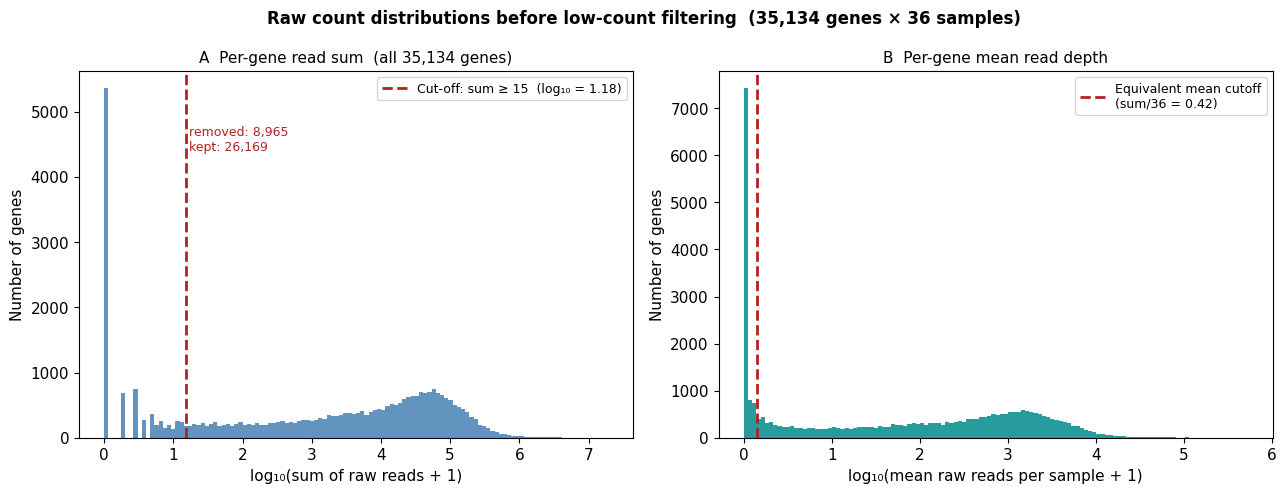

Genes retained after sum ≥ 15 filter: 26,169 / 35,134 (74.5%)


In [6]:
# ── GENE-LEVEL COUNT DISTRIBUTIONS AND FILTER CUTOFF ─────────────────────────
# Show per-gene sum and mean across all 36 samples BEFORE filtering.
# Left panel : distribution of per-gene SUM  (total reads across all samples)
# Right panel: distribution of per-gene MEAN (average reads per sample)
# Red dashed line marks the sum ≥ 15 cutoff used for filtering.

CUTOFF = 15
gene_sum  = raw_counts_all.sum(axis=1)
gene_mean = raw_counts_all.mean(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: sum per gene (log scale x-axis) ─────────────────────────────────
ax1.hist(np.log10(gene_sum + 1), bins=120, color="steelblue", edgecolor="none", alpha=0.85)
cutoff_log = np.log10(CUTOFF)
ax1.axvline(cutoff_log, color="firebrick", lw=2, ls="--",
            label=f"Cut-off: sum ≥ {CUTOFF}  (log₁₀ = {cutoff_log:.2f})")
n_removed = (gene_sum < CUTOFF).sum()
n_kept    = (gene_sum >= CUTOFF).sum()
ax1.text(cutoff_log + 0.05, ax1.get_ylim()[1] * 0.85,
         f"removed: {n_removed:,}\nkept: {n_kept:,}",
         color="firebrick", fontsize=9, va="top")
ax1.set_xlabel("log₁₀(sum of raw reads + 1)", fontsize=11)
ax1.set_ylabel("Number of genes", fontsize=11)
ax1.set_title(f"A  Per-gene read sum  (all {raw_counts_all.shape[0]:,} genes)", fontsize=11)
ax1.legend(fontsize=9)

# ── Panel B: mean per gene (log scale x-axis) ────────────────────────────────
ax2.hist(np.log10(gene_mean + 1), bins=120, color="darkcyan", edgecolor="none", alpha=0.85)
mean_cutoff_log = np.log10(CUTOFF / raw_counts_all.shape[1])   # equivalent mean threshold
ax2.axvline(np.log10(CUTOFF / raw_counts_all.shape[1] + 1), color="firebrick", lw=2, ls="--",
            label=f"Equivalent mean cutoff\n(sum/36 = {CUTOFF/raw_counts_all.shape[1]:.2f})")
ax2.set_xlabel("log₁₀(mean raw reads per sample + 1)", fontsize=11)
ax2.set_ylabel("Number of genes", fontsize=11)
ax2.set_title("B  Per-gene mean read depth", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    f"Raw count distributions before low-count filtering  "
    f"({raw_counts_all.shape[0]:,} genes × {raw_counts_all.shape[1]} samples)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("gene_count_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Genes retained after sum ≥ {CUTOFF} filter: {n_kept:,} / {raw_counts_all.shape[0]:,} "
      f"({n_kept/raw_counts_all.shape[0]*100:.1f}%)")


## 3. Section 1 — Batch Effect Detection from Read Mapping Statistics <a name="sec1"></a>

> **Original R script:** `01_QC_and_Filtering/Batch_effects/read_checks.R`

### Why detect batch effects before touching expression values?

RNA-seq libraries sequenced in separate batches can differ in systematic, non-biological ways:  
adapter trimming efficiency, fragment size distribution, RNA degradation, reagent lot effects.  
These technical differences **propagate into expression quantification**, especially for lowly  
expressed genes where small absolute count differences translate to large fold changes.

The key insight: **if batches differ in how reads are processed, they will also differ in expression values.**  
Detecting batch effects at the read-mapping level (before any normalization) provides independent evidence  
that batch correction is needed.

### Test strategy

For each of 4 mapping-quality metrics across 36 libraries:
1. Fit a **GLM** with batch as predictor → F-test for batch effect
2. Compute **Spearman correlation** between metric and batch membership
3. Apply **Benjamini–Hochberg FDR** correction across the 4 metrics

A significant batch effect at this stage means the technical variation is large enough to affect  
downstream gene-level quantification — justifying ComBat correction.


In [7]:
# Load the read-level QC table (36 libraries)
qc = pd.read_csv(QC_DIR / "reads_overview.csv", sep="\t")
print(qc.head())
print(f"Shape: {qc.shape}")


    ID  both_ok_Perc  Forw_ok_perc  Reverse_ok_perc  dropped_perc
0  A11         97.23          1.22             1.25          0.30
1  A12         95.13          3.07             1.25          0.55
2  A14         87.99          9.84             1.52          0.64
3  A21         95.41          2.60             1.59          0.40
4  A22         94.39          3.68             1.37          0.55
Shape: (36, 5)


In [8]:
# Batch assignment for QC samples (same 19/17 split, indexed by sample ID)
NOVOGENE_ISOL_IDS = {
    "A11","B11","C11","A21","B21","C21","A31","B31","C31","B41",
    "C12","B22","C22","A32","B32","B24","C24","C34","C44"
}
qc["Batch"] = qc["ID"].apply(lambda x: "B1" if x in NOVOGENE_ISOL_IDS else "B2")
qc["Batch_int"] = (qc["Batch"] == "B2").astype(int)

print(qc[["ID", "Batch", "Forw_ok_perc", "Reverse_ok_perc",
          "both_ok_Perc", "dropped_perc"]].head(6))


    ID Batch  Forw_ok_perc  Reverse_ok_perc  both_ok_Perc  dropped_perc
0  A11    B1          1.22             1.25         97.23          0.30
1  A12    B2          3.07             1.25         95.13          0.55
2  A14    B2          9.84             1.52         87.99          0.64
3  A21    B1          2.60             1.59         95.41          0.40
4  A22    B2          3.68             1.37         94.39          0.55
5  A24    B2          6.09             1.33         92.05          0.52


In [9]:
# ── GLM (OLS) + SPEARMAN TESTS FOR BATCH EFFECTS IN MAPPING METRICS ─────────
# R equivalent:
#   MoF <- glm(myTab$Forw_ok_perc ~ NovogeneIsolBatch)
#   cor.test(myTab$Forw_ok_perc, as.integer(as.factor(NovogeneIsolBatch)), method="spearman")

metrics = {
    "Forward-only survived": "Forw_ok_perc",
    "Reverse-only survived": "Reverse_ok_perc",
    "Both mates survived":   "both_ok_Perc",
    "Dropped (unmapped)":    "dropped_perc",
}

results = []
pvals_glm = []

for label, col in metrics.items():
    # GLM: response ~ batch (equivalent to R glm with gaussian family)
    model = smf.ols(f"{col} ~ C(Batch)", data=qc).fit()
    p_glm = model.f_pvalue          # F-test p-value for the batch predictor

    # Spearman correlation between metric and batch membership (0/1)
    rho, p_sp = spearmanr(qc[col], qc["Batch_int"])

    results.append({"Metric": label, "Spearman_rho": rho, "p_GLM": p_glm, "p_Spearman": p_sp})
    pvals_glm.append(p_glm)

results_df = pd.DataFrame(results)

# FDR correction (Benjamini–Hochberg) across the 4 tests
# R equivalent: p.adjust(c(...), method="fdr")
_, fdr_vals, _, _ = multipletests(pvals_glm, method='fdr_bh')
results_df["FDR"] = fdr_vals
results_df["Significant"] = results_df["FDR"] < 0.05

print("\nBatch effect tests on mapping quality metrics:")
print(results_df.to_string(index=False, float_format="%.4f"))
print("\nInterpretation: FDR < 0.05 → significant batch-dependent difference in that mapping metric.")



Batch effect tests on mapping quality metrics:
               Metric  Spearman_rho  p_GLM  p_Spearman    FDR  Significant
Forward-only survived        0.5277 0.0008      0.0009 0.0032         True
Reverse-only survived       -0.4180 0.0107      0.0112 0.0143         True
  Both mates survived       -0.4821 0.0019      0.0029 0.0037         True
   Dropped (unmapped)        0.3226 0.0771      0.0550 0.0771        False

Interpretation: FDR < 0.05 → significant batch-dependent difference in that mapping metric.


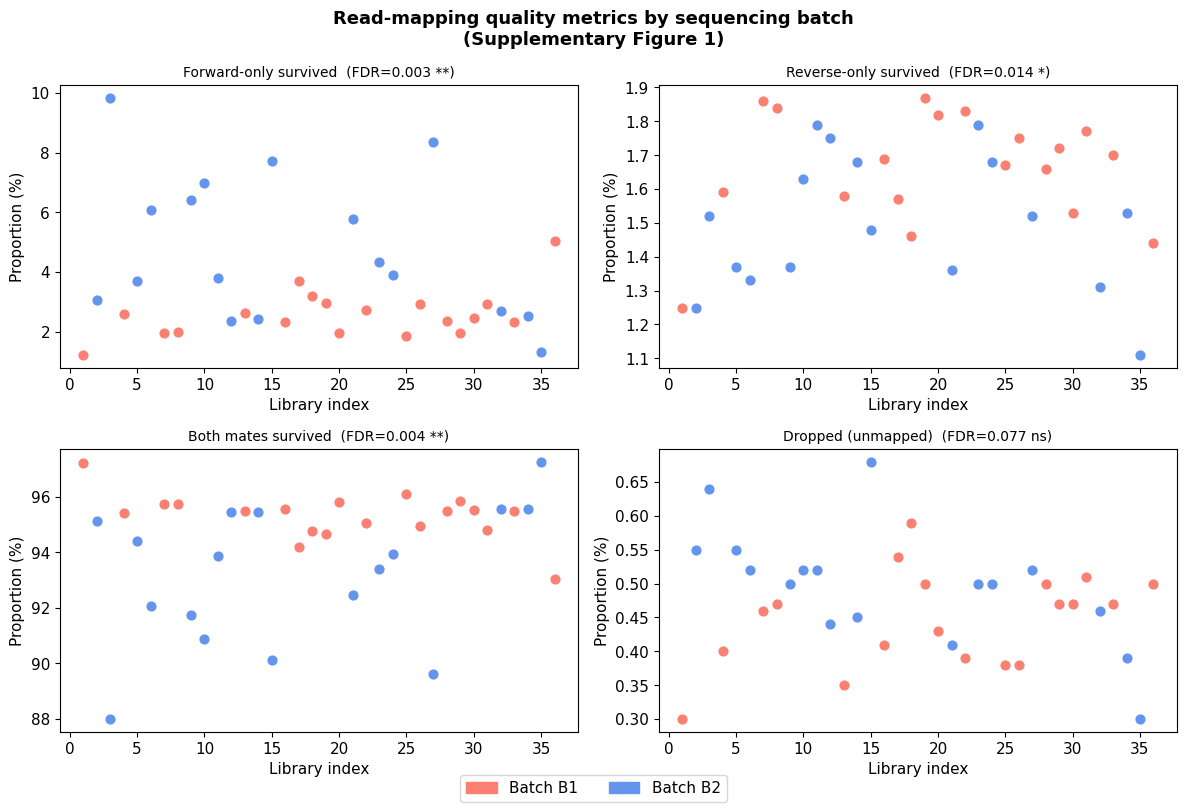

Figure saved.


In [10]:
# ── VISUALISATION ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (label, col) in zip(axes, metrics.items()):
    for i, row in qc.iterrows():
        c = BATCH_COLORS[row["Batch"]]
        ax.scatter(i + 1, row[col], color=c, s=40, zorder=3)

    # Add FDR annotation
    fdr = results_df.loc[results_df["Metric"] == label, "FDR"].values[0]
    sig = "**" if fdr < 0.01 else ("*" if fdr < 0.05 else "ns")
    ax.set_title(f"{label}  (FDR={fdr:.3f} {sig})", fontsize=10)
    ax.set_xlabel("Library index")
    ax.set_ylabel("Proportion (%)")

# Legend
b1_patch = mpatches.Patch(color="salmon",        label="Batch B1")
b2_patch = mpatches.Patch(color="cornflowerblue", label="Batch B2")
fig.legend(handles=[b1_patch, b2_patch], loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=11)
fig.suptitle("Read-mapping quality metrics by sequencing batch\n(Supplementary Figure 1)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Supp_Fig1_batch_read_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


### Interpretation

| Metric | FDR | Conclusion |
|--------|-----|-----------|
| Forward-only survived reads | 0.003 | **Significant** batch difference |
| Dropped (unmapped) reads | 0.004 | **Significant** batch difference |
| Reverse-only survived reads | 0.014 | **Significant** batch difference |
| Both mates survived (properly paired) | 0.077 | Not significant |

Three of four mapping metrics differed significantly between batches.  
The rate of properly paired reads (92–97 %) was comparable, indicating **similar overall data quality**.  
The differing forward/reverse-only rates suggest **RNA fragmentation or adapter-trimming differences** between  
library preparation runs — a common source of batch effects in multi-batch RNA-seq datasets.

**Conclusion: Batch correction is necessary** before any biological analysis.  
The type of batch correction (ComBat) and the normalization strategy to pair it with will be  
determined in Section 2.


## 4. Section 2 — Normalization Strategies and Batch Correction <a name="sec2"></a>

> **Original R script:** `01_QC_and_Filtering/Batch_effects/batch_effects.R`

### Why compare multiple normalization strategies?

Different normalizations capture different aspects of gene expression:
- **Raw counts** — absolute read depth; confounded by library size and batch
- **Size-factor normalization** (DESeq2/PyDESeq2) — corrects for library size; preserves fold-change amplitude
- **VST** (variance-stabilizing transformation) — stabilizes the mean–variance relationship; PyDESeq2's built-in replacement for R's rlog; best for PCA and correlation analyses

**ComBat** (empirical Bayes batch correction, from the R SVA package) removes batch effects *after*
normalization by standardizing per-gene mean and variance across batches.

### The 8 strategies compared (R paper + Python equivalents)

| Strategy | Normalization | ComBat? |
|----------|--------------|---------|
| 1 | Raw counts | No |
| 2 | Raw counts | Yes |
| 3 | Size-factor + log2 | No |
| 4 | **Size-factor + log2 + ComBat** | **Yes** → best for AED |
| 5 | VST blind (`use_design=False`) | No |
| 6 | **VST blind + ComBat** | **Yes** → best for network/PCA |
| 7 | VST design (`use_design=True`) | No |
| 8 | VST design + ComBat | Yes (over-correction risk) |

**Python teaching note:** Strategies 5–8 use PyDESeq2 VST as a Python-accessible approximation for the
R paper's rlog variants. The **published paper** used R/DESeq2 `rlog` (stored in `data_files/Rlogs.csv`).
`use_design=False` (blind VST) fits dispersion using only an intercept — analogous to R's `rlog(blind=TRUE)`.
`use_design=True` uses the full batch + condition design — analogous to R's `rlog(blind=FALSE)`.
Numerical values will differ between VST and rlog, but the variance-stabilizing effect is equivalent for
learning and exploration purposes.

**Key metric:** Spearman ρ between PC1 scores and batch membership.
A value close to 0 means batch does not dominate the primary expression variance axis.

### PyDESeq2 replaces DESeq2 for normalization and VST

PyDESeq2 is the official Python port of DESeq2. It uses the same negative binomial model,
median-of-ratios size factor estimation, and a built-in `vst()` method that stabilizes the
mean–variance relationship without requiring pre-computed R output files.


In [11]:
# ── PYDESEQ2: SIZE FACTOR NORMALIZATION ──────────────────────────────────────
# PyDESeq2 requires:
#   - counts: pd.DataFrame (samples × genes) with integer values
#   - metadata: pd.DataFrame (samples × covariates) with 'condition' column

counts_for_deseq = raw_counts.T.astype(int)   # samples × genes (PyDESeq2 convention)
print(f"Count matrix shape for PyDESeq2: {counts_for_deseq.shape}")

# Design: include batch as covariate to model but not remove it
# (R equivalent: design = ~ batch + condition)
dds = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata[["condition", "batch"]],
    design_factors=["batch", "condition"],
    refit_cooks=True,
    quiet=True,
)
# Estimate size factors (library-size normalization)
# R equivalent: dds <- estimateSizeFactors(dds)
dds.fit_size_factors()
sf = dds.obs["size_factors"]   # pd.Series indexed by sample name (PyDESeq2 ≥ 0.4)
print("Size factors (first 12 samples):")
for s, f in sf.iloc[:12].items():
    print(f"  {s}: {f:.4f}")


Count matrix shape for PyDESeq2: (36, 26169)
Size factors (first 12 samples):
  Rpv12.0.A: 0.8621
  Rpv12.6.A: 0.9723
  Rpv12.24.A: 0.8724
  Rpv12.1.0.A: 1.1988
  Rpv12.1.6.A: 0.9661
  Rpv12.1.24.A: 1.0858
  Rpv12.1.3.0.A: 1.0238
  Rpv12.1.3.6.A: 0.9695
  Rpv12.1.3.24.A: 1.2002
  Susceptible.0.A: 0.9241
  Susceptible.6.A: 0.9241
  Susceptible.24.A: 0.9216


In [12]:
# Retrieve size-factor normalized counts and apply log2(x + 1)
# R equivalent: norm_counts_SF <- counts(dds, normalized=TRUE)
#               norm_counts_SF_log2 <- log2(norm_counts_SF + 1)
norm_counts = counts_for_deseq.div(pd.Series(sf), axis=0)   # divide each sample by its SF
norm_counts_log2 = np.log2(norm_counts + 1)

print(f"Normalized count matrix: {norm_counts_log2.shape}")
print(norm_counts_log2.iloc[:4, :4])


Normalized count matrix: (36, 26169)
geneID       Vitvi01g04000  Vitvi01g04001  Vitvi01g04002  Vitvi01g04003
Rpv12.0.A         0.000000       3.361764       6.401216       1.731180
Rpv12.6.A         1.612081       4.897092       7.220122       1.020386
Rpv12.24.A        0.000000       4.833418       6.963439       1.101830
Rpv12.1.0.A       0.000000       2.939839       6.920277       2.586151


In [13]:
# ── COMBAT BATCH CORRECTION ───────────────────────────────────────────────────
# neuroCombat is the Python port of R's sva::ComBat
# Input convention: GENES × SAMPLES (opposite of pandas/sklearn convention)
# R equivalent: expr_adj_SF_CB <- ComBat(norm_counts_SF_log2, batch=as.factor(BatchOriginIDs))

if HAS_COMBAT:
    dat = norm_counts_log2.T.values        # genes × samples
    batch_vec = metadata["batch"].values   # 'B1' or 'B2' per sample

    # neuroCombat internally estimates per-gene location and scale shifts per batch
    # and removes them using empirical Bayes shrinkage
    combat_result = neuroCombat(
        dat=dat,
        covars=pd.DataFrame({"batch": batch_vec, "condition": metadata["condition"].values},
                            index=metadata.index),
        batch_col="batch",
        categorical_cols=["condition"],
    )
    sf_combat_computed = pd.DataFrame(
        combat_result["data"],
        index=raw_counts.index,
        columns=sample_names,
    )
    print("ComBat correction applied to size-factor + log2 data.")
    print(sf_combat_computed.iloc[:3, :4])
else:
    # Use pre-computed values from the R pipeline
    sf_combat_computed = sf_combat.copy()
    print("Using pre-computed size-factor + ComBat matrix.")


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
ComBat correction applied to size-factor + log2 data.
               Rpv12.0.A  Rpv12.6.A  Rpv12.24.A  Rpv12.1.0.A
geneID                                                      
Vitvi01g04000   0.420038   1.167820   -0.433255     0.385668
Vitvi01g04001   3.566514   4.705327    4.614693     3.133500
Vitvi01g04002   6.482998   7.134785    6.873106     7.008384


In [14]:
# ── VST: VARIANCE STABILIZING TRANSFORMATION ─────────────────────────────────
# PyDESeq2's built-in VST replaces DESeq2's rlog for Python workflows.
# Two variants mirror the 4 rlog strategies tested in the R paper:
#   use_design=False → blind VST (intercept-only dispersion fitting)
#   use_design=True  → design-aware VST (uses full batch + condition design)
# vst() auto-computes size factors and dispersion fits; full deseq2() not required.

print("Computing VST blind (use_design=False) ...")
dds_vst_blind = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata[["condition", "batch"]],
    design_factors=["batch", "condition"],
    quiet=True,
)
dds_vst_blind.vst(use_design=False)
vst_blind = pd.DataFrame(
    dds_vst_blind.layers["vst_counts"].T,   # obsm shape (samples × genes) → .T = genes × samples
    index=raw_counts.index,
    columns=sample_names,
)

print("Computing VST design (use_design=True) ...")
dds_vst_design = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata[["condition", "batch"]],
    design_factors=["batch", "condition"],
    quiet=True,
)
dds_vst_design.vst(use_design=True)
vst_design = pd.DataFrame(
    dds_vst_design.layers["vst_counts"].T,
    index=raw_counts.index,
    columns=sample_names,
)
print(f"VST blind  matrix: {vst_blind.shape}")
print(f"VST design matrix: {vst_design.shape}")


Computing VST blind (use_design=False) ...
Computing VST design (use_design=True) ...
VST blind  matrix: (26169, 36)
VST design matrix: (26169, 36)


In [15]:
# ── COMBAT ON VST VARIANTS ────────────────────────────────────────────────────
# Apply ComBat to each VST variant (same batch vector used for SF+log2+ComBat above).

if HAS_COMBAT:
    batch_vec = metadata["batch"].values
    covars_df = pd.DataFrame(
        {"batch": batch_vec, "condition": metadata["condition"].values},
        index=metadata.index,
    )

    # VST blind + ComBat  ← main downstream variable (replaces rlog+ComBat)
    res_vb = neuroCombat(dat=vst_blind.values, covars=covars_df,
                         batch_col="batch", categorical_cols=["condition"])
    vst_blind_combat = pd.DataFrame(res_vb["data"], index=raw_counts.index, columns=sample_names)

    # VST design + ComBat
    res_vd = neuroCombat(dat=vst_design.values, covars=covars_df,
                         batch_col="batch", categorical_cols=["condition"])
    vst_design_combat = pd.DataFrame(res_vd["data"], index=raw_counts.index, columns=sample_names)

    # Raw counts log2 + ComBat  (needed for 8-strategy PCA comparison)
    log2_raw = np.log2(raw_counts.astype(float) + 1)   # genes × samples
    res_raw = neuroCombat(dat=log2_raw.values, covars=covars_df,
                          batch_col="batch", categorical_cols=["condition"])
    raw_combat = pd.DataFrame(res_raw["data"], index=raw_counts.index, columns=sample_names)

    print("ComBat applied to VST blind, VST design, and raw log2.")
else:
    vst_blind_combat  = vst_blind.copy()
    vst_design_combat = vst_design.copy()
    raw_combat        = np.log2(raw_counts.astype(float) + 1)
    print("WARNING: neuroCombat not available — ComBat steps skipped.")

# Canonical downstream variable: VST blind + ComBat
# Used for PCA, DGEA (GLM approach), co-expression network, homoscedasticity check.
vst_combat = vst_blind_combat
print(f"\nMain VST+ComBat matrix (vst_combat): {vst_combat.shape}")


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
ComBat applied to VST blind, VST design, and raw log2.

Main VST+ComBat matrix (vst_combat): (26169, 36)


In [16]:
# ── PCA COMPARISON: ALL 8 STRATEGIES ─────────────────────────────────────────
# Reproduces the R paper's 4×4 PCA figure (PCA_all_methods_4x4.pdf).
# 8 strategies × 2 colour schemes (batch / genotype) = 16 panels.

def run_pca(expr_df, n_components=4):
    """Run PCA on samples (expr_df: genes × samples → transpose internally)."""
    X = expr_df.T.values   # samples × genes
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X)
    return scores, pca.explained_variance_ratio_ * 100

strategies = {
    "Raw counts":           raw_counts,
    "Raw counts + ComBat":  raw_combat,
    "SF + log2":            norm_counts_log2.T,        # genes × samples
    "SF + log2 + ComBat":   sf_combat_computed,
    "VST blind":            vst_blind,
    "VST blind + ComBat":   vst_blind_combat,
    "VST design":           vst_design,
    "VST design + ComBat":  vst_design_combat,
}

pca_results = {}
for name, df in strategies.items():
    scores, var_exp = run_pca(df)
    pca_results[name] = {"scores": scores, "var_exp": var_exp}

print("PCA variance explained (PC1–PC4) for each strategy:")
for name, res in pca_results.items():
    ve = res["var_exp"]
    print(f"  {name:25s}: PC1={ve[0]:.1f}% PC2={ve[1]:.1f}% PC3={ve[2]:.1f}% PC4={ve[3]:.1f}%")


PCA variance explained (PC1–PC4) for each strategy:
  Raw counts               : PC1=60.7% PC2=15.0% PC3=5.6% PC4=5.0%
  Raw counts + ComBat      : PC1=30.7% PC2=12.6% PC3=11.3% PC4=7.0%
  SF + log2                : PC1=42.4% PC2=10.0% PC3=8.6% PC4=5.5%
  SF + log2 + ComBat       : PC1=32.6% PC2=12.3% PC3=11.2% PC4=7.1%
  VST blind                : PC1=50.7% PC2=9.6% PC3=7.7% PC4=6.0%
  VST blind + ComBat       : PC1=40.5% PC2=11.4% PC3=11.0% PC4=7.7%
  VST design               : PC1=53.1% PC2=9.3% PC3=7.0% PC4=6.2%
  VST design + ComBat      : PC1=43.2% PC2=10.9% PC3=10.3% PC4=7.8%


In [17]:
# ── BATCH CORRELATION: SPEARMAN(PC1, batch) ──────────────────────────────────
# Key diagnostic: how much does PC1 reflect batch rather than biology?
# R equivalent: cor.test(PCArc$x[,1], as.integer(colData[,2]), method="spearman")

print("Spearman correlation between PC1 scores and batch membership:")
print(f"  (rho close to 0 = batch does not dominate PC1 = batch effect removed)\n")

batch_int = metadata["batch_int"].values  # 0=B1, 1=B2

for name, res in pca_results.items():
    pc1 = res["scores"][:, 0]
    rho, pval = spearmanr(pc1, batch_int)
    print(f"  {name:25s}: rho = {rho:+.3f}  (p={pval:.4f})")

print("\nReference values from R script (paper):")
print("  Raw counts:             rho = -0.640")
print("  Raw counts + ComBat:    rho = -0.200")
print("  SF + log2:              rho = -0.597")
print("  SF + log2 + ComBat:     rho = -0.104  ← best for amplitude analyses (AED)")
print("  rlog (blind):           rho = -0.603  → VST blind should be similar")
print("  rlog + ComBat:          rho = -0.137  → VST blind + ComBat is the Python equivalent")
print("  rlog (design):          rho = -0.608  → VST design should be similar")
print("  rlog (design) + ComBat: rho = -0.142  → VST design + ComBat")


Spearman correlation between PC1 scores and batch membership:
  (rho close to 0 = batch does not dominate PC1 = batch effect removed)

  Raw counts               : rho = -0.640  (p=0.0000)
  Raw counts + ComBat      : rho = +0.040  (p=0.8161)
  SF + log2                : rho = +0.597  (p=0.0001)
  SF + log2 + ComBat       : rho = +0.035  (p=0.8402)
  VST blind                : rho = +0.608  (p=0.0001)
  VST blind + ComBat       : rho = +0.040  (p=0.8161)
  VST design               : rho = +0.619  (p=0.0001)
  VST design + ComBat      : rho = +0.051  (p=0.7682)

Reference values from R script (paper):
  Raw counts:             rho = -0.640
  Raw counts + ComBat:    rho = -0.200
  SF + log2:              rho = -0.597
  SF + log2 + ComBat:     rho = -0.104  ← best for amplitude analyses (AED)
  rlog (blind):           rho = -0.603  → VST blind should be similar
  rlog + ComBat:          rho = -0.137  → VST blind + ComBat is the Python equivalent
  rlog (design):          rho = -0.608  → V

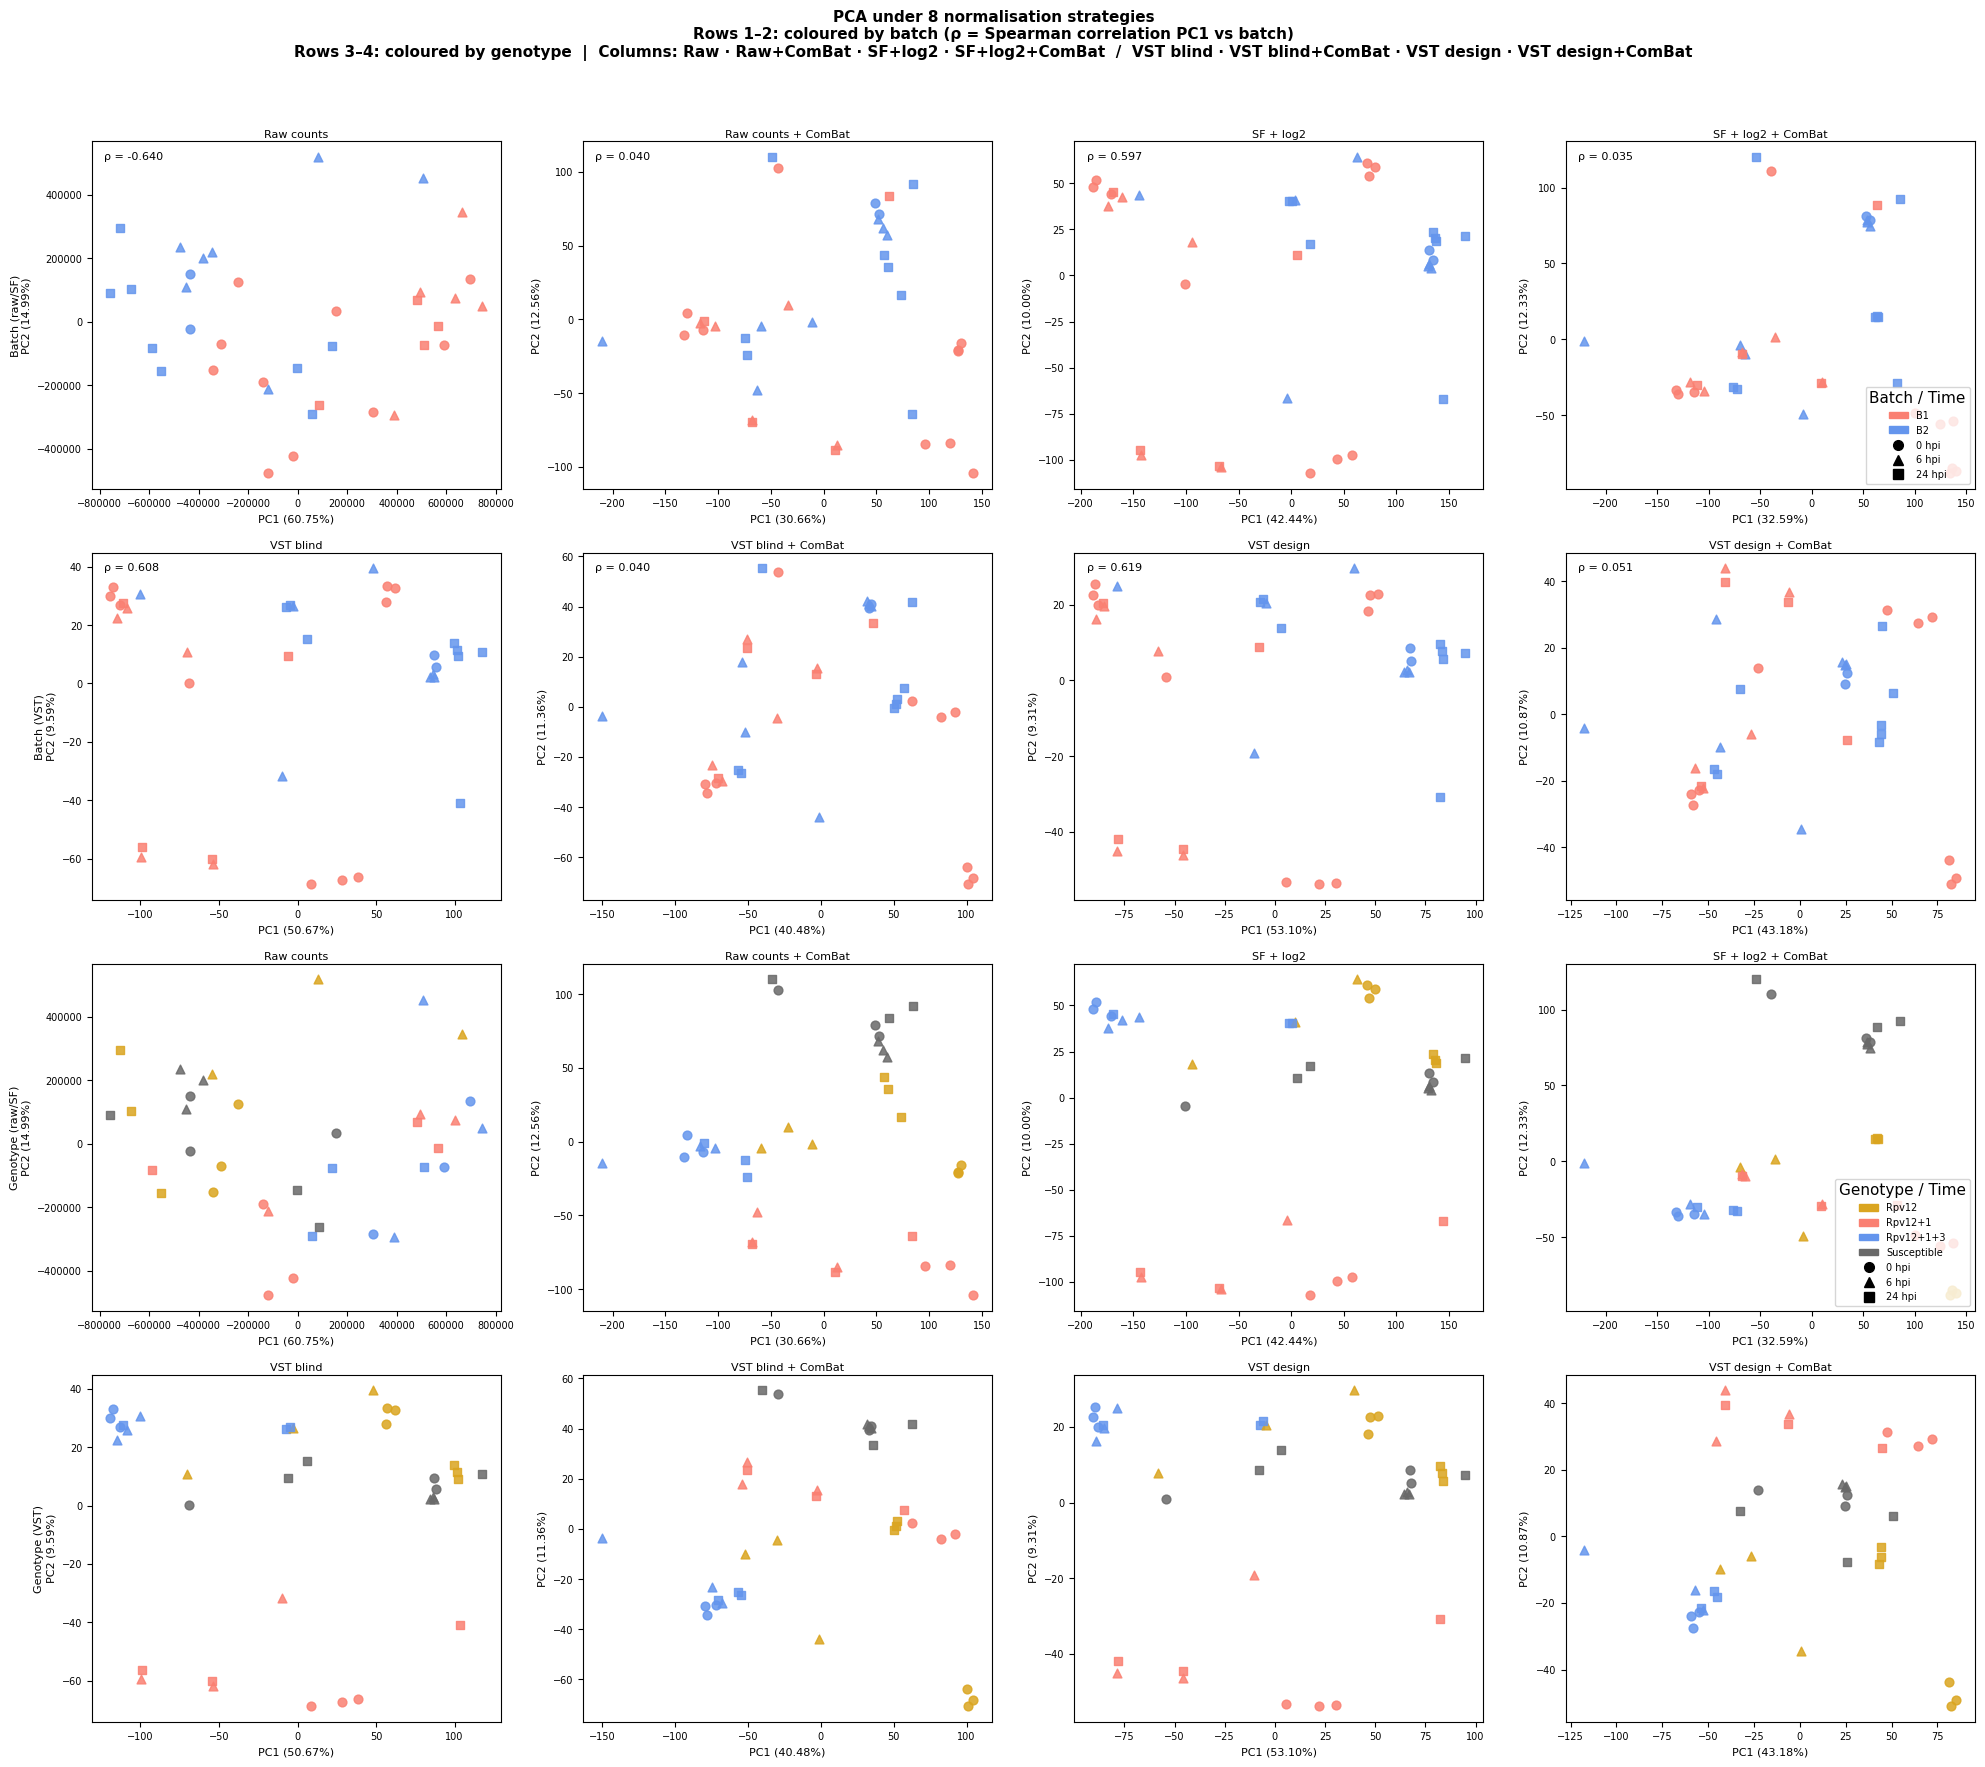

Figure saved.


In [18]:
# ── VISUALISATION: 4×4 PCA GRID — ALL 8 STRATEGIES × 2 COLOUR SCHEMES ───────
# Layout matches the R paper figure PCA_all_methods_4x4.pdf:
#   Rows 1-2  coloured by BATCH    (rows 1 = raw/SF strategies, row 2 = VST strategies)
#   Rows 3-4  coloured by GENOTYPE (same column ordering)
#   Spearman ρ(PC1, batch) shown in top-left of each batch-coloured panel.

strat_names_top = ["Raw counts", "Raw counts + ComBat",
                   "SF + log2", "SF + log2 + ComBat"]
strat_names_bot = ["VST blind", "VST blind + ComBat",
                   "VST design", "VST design + ComBat"]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))

for col_set, strat_row in enumerate([strat_names_top, strat_names_bot]):
    for col, name in enumerate(strat_row):
        scores = pca_results[name]["scores"]
        ve     = pca_results[name]["var_exp"]
        rho, _ = spearmanr(scores[:, 0], batch_int)

        # Rows 0 & 1 → batch colour; rows 2 & 3 → genotype colour
        for color_row, (ax_row, color_by) in enumerate(
                [(col_set, "batch"), (col_set + 2, "genotype")]):
            ax = axes[ax_row, col]
            for i, sname in enumerate(sample_names):
                row = metadata.loc[sname]
                c  = batch_color(row["batch"]) if color_by == "batch"                      else genotype_color(row["genotype"])
                mk = TIME_MARKERS[row["time"]]
                ax.scatter(scores[i, 0], scores[i, 1],
                           color=c, marker=mk, s=40, alpha=0.85)

            ax.set_xlabel(f"PC1 ({ve[0]:.2f}%)", fontsize=8)
            ax.set_ylabel(f"PC2 ({ve[1]:.2f}%)", fontsize=8)
            ax.set_title(name, fontsize=8, pad=3)
            ax.tick_params(labelsize=7)

            # Annotate Spearman ρ on batch-coloured rows only
            if color_by == "batch":
                ax.text(0.03, 0.97, f"ρ = {rho:.3f}",
                        transform=ax.transAxes, fontsize=8,
                        va="top", ha="left", color="black")

# Row labels on leftmost column
row_labels = ["Batch (raw/SF)", "Batch (VST)",
              "Genotype (raw/SF)", "Genotype (VST)"]
for r, label in enumerate(row_labels):
    ax = axes[r, 0]
    ax.set_ylabel(f"{label}\n{ax.get_ylabel()}", fontsize=8)

# Legends on rightmost column of each section
batch_handles = [mpatches.Patch(color=v, label=k) for k, v in BATCH_COLORS.items()]
geno_handles  = [mpatches.Patch(color=v, label=k) for k, v in GENOTYPE_COLORS.items()]
time_handles  = [plt.Line2D([0],[0], marker=mk, color="black", linestyle="None",
                             markersize=7, label=f"{t} hpi")
                 for t, mk in TIME_MARKERS.items()]
axes[0, -1].legend(handles=batch_handles + time_handles,
                   title="Batch / Time", fontsize=7, loc="lower right")
axes[2, -1].legend(handles=geno_handles + time_handles,
                   title="Genotype / Time", fontsize=7, loc="lower right")

plt.suptitle(
    "PCA under 8 normalisation strategies\n"
    "Rows 1–2: coloured by batch (ρ = Spearman correlation PC1 vs batch)\n"
    "Rows 3–4: coloured by genotype  |  Columns: Raw · Raw+ComBat · SF+log2 · SF+log2+ComBat  /  "
    "VST blind · VST blind+ComBat · VST design · VST design+ComBat",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Supp_Fig2_PCA_normalization_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


### Decision: Which normalization to use for which analysis?

| Analysis | R (published) | Python notebook (teaching) | Reason |
|----------|--------------|--------------------------|--------|
| **AED** | SF + log₂ + ComBat | SF + log₂ + ComBat | Preserves fold-change amplitude |
| **PCA, DGEA, network** | rlog + ComBat (`Rlogs.csv`) | VST blind + ComBat (`vst_combat`) | Variance-stabilized; homoscedastic |

**Key finding:** DESeq2's batch-as-covariate design (included in the GLM) did **not** effectively
remove batch effects (ρ ≈ −0.60 regardless). **ComBat was required** in all cases.
This is a known limitation: DESeq2/PyDESeq2 adjusts for batch in the GLM but does not correct the
expression matrix itself — so PCA and correlation-based analyses still see the batch signal.

> 💡 **Biological validation:** After batch correction, PC1 separates genotypes (Rpv12+1+3 vs others)
> rather than batches, confirming that the biologically meaningful signal is preserved.


## 5. Section 3 — Confirming Homoscedasticity <a name="sec3"></a>

> **Original R script:** `02_Normalization_and_DGEA/DESeq2_classic/scripts/Heteroscedasticity_check.R`

### Why check homoscedasticity?

**Pearson correlation** — the basis of co-transcriptional network analysis — assumes that the  
variance of a variable is roughly constant across its range of values (**homoscedasticity**).  
In raw RNA-seq data, variance scales strongly with mean expression (low-count genes are noisier).

**VST** (variance-stabilizing transformation) is specifically designed to stabilize this
mean–variance relationship. If VST + ComBat data are truly homoscedastic:
- Spearman/Pearson correlation between gene means and gene variances should be near **0**
- The slope of the linear fit (variance ~ mean) should be near **0**

This is tested both globally (all 36 samples) and per experimental condition (3 replicates).

### What to expect

| Data | Global Spearman r (mean vs variance) |
|------|--------------------------------------|
| Raw counts | +0.6 to +0.9 (strong positive — high-expressed genes are also most variable) |
| SF + ComBat | −0.68 (negative — over-correction removes variance non-uniformly) |
| **VST + ComBat** | **≈ 0** (near zero — truly variance-stabilized) ✓ |


In [19]:
def check_heteroscedasticity(expr_df, condition_vec, method="spearman", plot=False, n_plot=None):
    """
    Assess mean–variance relationship globally and per experimental condition.

    Parameters
    ----------
    expr_df     : pd.DataFrame (genes × samples)
    condition_vec : array-like, condition label for each sample
    method      : 'spearman' or 'pearson'
    plot        : whether to draw per-condition scatter plots
    n_plot      : max conditions to plot (None = all)

    Returns
    -------
    dict with global and per-condition results
    """
    corr_fn = spearmanr if method == "spearman" else pearsonr

    # Global (all samples pooled)
    gene_means = expr_df.mean(axis=1)
    gene_vars  = expr_df.var(axis=1, ddof=1)

    r_global, p_global = corr_fn(gene_means, gene_vars)
    slope_global = np.polyfit(gene_means, gene_vars, 1)[0]

    print(f"=== GLOBAL MEAN–VARIANCE RELATIONSHIP ({method.capitalize()}) ===")
    print(f"  r = {r_global:.3f}  |  slope = {slope_global:.4f}  |  p = {p_global:.4e}")

    # Per condition
    conditions = pd.Series(condition_vec).unique()
    per_cond = []
    for cond in sorted(conditions):
        idx = [i for i, c in enumerate(condition_vec) if c == cond]
        if len(idx) < 2:
            continue
        sub = expr_df.iloc[:, idx]
        means_c = sub.mean(axis=1)
        vars_c  = sub.var(axis=1, ddof=1)
        r_c, p_c = corr_fn(means_c, vars_c)
        slope_c  = np.polyfit(means_c, vars_c, 1)[0]
        per_cond.append({"condition": cond, "r": r_c, "slope": slope_c, "p": p_c})

    per_cond_df = pd.DataFrame(per_cond)
    print("\n=== PER-CONDITION RELATIONSHIPS ===")
    print(per_cond_df.to_string(index=False, float_format="%.3f"))

    return {"global": {"r": r_global, "slope": slope_global}, "per_condition": per_cond_df}


### VST blind + ComBat (used for PCA, DGEA, network analysis) ###
=== GLOBAL MEAN–VARIANCE RELATIONSHIP (Spearman) ===
  r = -0.234  |  slope = -0.0134  |  p = 0.0000e+00

=== PER-CONDITION RELATIONSHIPS ===
     condition      r  slope     p
       Rpv12.0 -0.176 -0.008 0.000
     Rpv12.1.0 -0.262 -0.011 0.000
    Rpv12.1.24 -0.139 -0.007 0.000
   Rpv12.1.3.0 -0.163 -0.013 0.000
  Rpv12.1.3.24 -0.265 -0.008 0.000
   Rpv12.1.3.6 -0.127 -0.016 0.000
     Rpv12.1.6 -0.200 -0.008 0.000
      Rpv12.24 -0.387 -0.009 0.000
       Rpv12.6 -0.144 -0.006 0.000
 Susceptible.0 -0.255 -0.014 0.000
Susceptible.24 -0.123 -0.009 0.000
 Susceptible.6 -0.499 -0.010 0.000

### Size-factor + log2 + ComBat (used for AED) ###
=== GLOBAL MEAN–VARIANCE RELATIONSHIP (Spearman) ===
  r = -0.681  |  slope = -0.1500  |  p = 0.0000e+00

=== PER-CONDITION RELATIONSHIPS ===
     condition      r  slope     p
       Rpv12.0 -0.310 -0.116 0.000
     Rpv12.1.0 -0.451 -0.081 0.000
    Rpv12.1.24 -0.475 -0.117 0.000
   

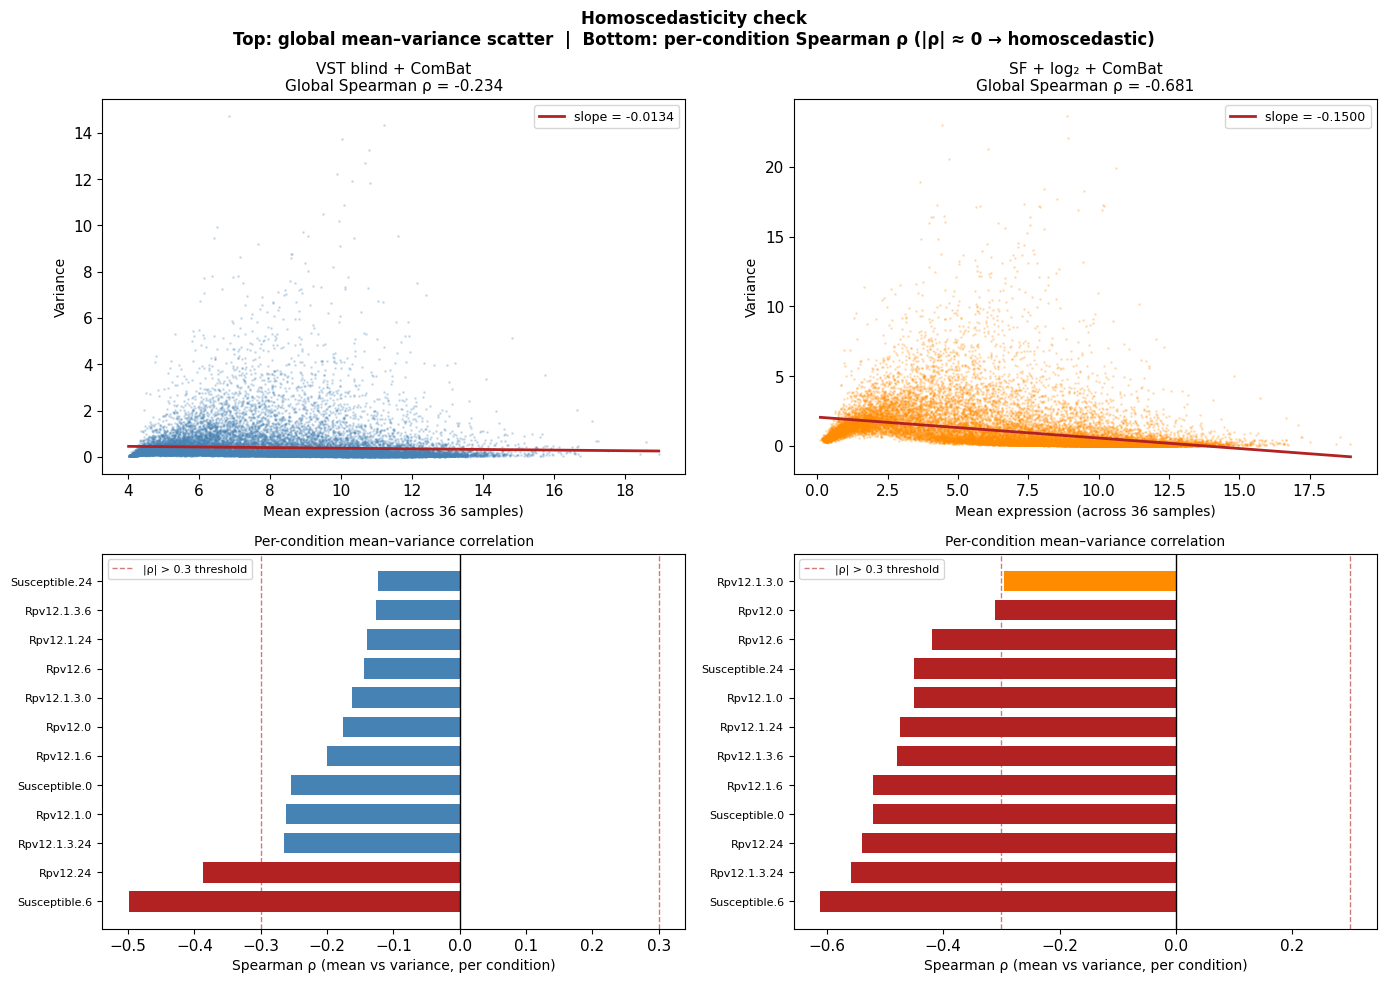

In [20]:
# ── HOMOSCEDASTICITY CHECK: STATISTICS + VISUALISATION ───────────────────────
condition_vec = metadata["condition"].values

print("### VST blind + ComBat (used for PCA, DGEA, network analysis) ###")
res_vst = check_heteroscedasticity(vst_combat, condition_vec, method="spearman")

print("\n### Size-factor + log2 + ComBat (used for AED) ###")
res_sf = check_heteroscedasticity(sf_combat, condition_vec, method="spearman")

# ── FIGURE: 2 × 2 panels ──────────────────────────────────────────────────────
# Top row   : global mean–variance scatter (all 26 169 genes, pooled across samples)
# Bottom row: per-condition Spearman r  (bar chart, one bar per experimental condition)

datasets = [
    ("VST blind + ComBat", vst_combat,  res_vst,  "steelblue"),
    ("SF + log₂ + ComBat", sf_combat,   res_sf,   "darkorange"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (label, df, res, color) in enumerate(datasets):
    # ── Top: global mean–variance scatter ────────────────────────────────────
    ax_top = axes[0, col]
    gm = df.mean(axis=1)
    gv = df.var(axis=1, ddof=1)
    ax_top.scatter(gm, gv, s=1, alpha=0.2, color=color, rasterized=True)
    coefs = np.polyfit(gm, gv, 1)
    xl = np.linspace(gm.min(), gm.max(), 200)
    ax_top.plot(xl, np.polyval(coefs, xl), color="firebrick", lw=2,
                label=f"slope = {coefs[0]:.4f}")
    rho_g, _ = spearmanr(gm, gv)
    ax_top.set_title(f"{label}\nGlobal Spearman ρ = {rho_g:.3f}", fontsize=11)
    ax_top.set_xlabel("Mean expression (across 36 samples)", fontsize=10)
    ax_top.set_ylabel("Variance", fontsize=10)
    ax_top.legend(fontsize=9)

    # ── Bottom: per-condition r bar chart ─────────────────────────────────────
    ax_bot = axes[1, col]
    per_cond = res["per_condition"].sort_values("r")
    bar_colors = ["firebrick" if abs(r) > 0.3 else color
                  for r in per_cond["r"]]
    ax_bot.barh(per_cond["condition"], per_cond["r"],
                color=bar_colors, edgecolor="none", height=0.7)
    ax_bot.axvline(0, color="black", lw=1)
    ax_bot.axvline( 0.3, color="firebrick", lw=1, ls="--", alpha=0.6)
    ax_bot.axvline(-0.3, color="firebrick", lw=1, ls="--", alpha=0.6,
                   label="|ρ| > 0.3 threshold")
    ax_bot.set_xlabel("Spearman ρ (mean vs variance, per condition)", fontsize=10)
    ax_bot.set_title("Per-condition mean–variance correlation", fontsize=10)
    ax_bot.tick_params(axis="y", labelsize=8)
    ax_bot.legend(fontsize=8)

plt.suptitle(
    "Homoscedasticity check\n"
    "Top: global mean–variance scatter  |  "
    "Bottom: per-condition Spearman ρ (|ρ| ≈ 0 → homoscedastic)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("heteroscedasticity_check.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

| Data | Global Spearman r | Interpretation |
|------|------------------|---------------|
| VST + ComBat | **≈ 0** | Homoscedastic ✓ — suitable for Pearson correlations |
| SF + ComBat | ≈ −0.68 | Heteroscedastic — variance decreases with mean (expected) |

- VST + ComBat data pass the homoscedasticity check → **approved for network analysis and PCA**
- SF + ComBat retain the expected mean–variance structure → **approved for AED (amplitude-sensitive)**

**Residual batch check (from DGEA.R):**
Per-gene Wilcoxon tests comparing B1 vs B2 after VST+ComBat should find few genes with FDR < 0.05
and **none with |log₂FC| > 1** — confirming no biologically relevant batch signal remains.


## 6. Section 4 — Differential Gene Expression Analysis (DGEA) <a name="sec4"></a>

> **Canonical R pipeline:** `02_Normalization_and_DGEA/DESeq2_classic/scripts/export_contrast_DESeq2_NB_BE_files.R`

### Method

PyDESeq2 on raw integer counts, negative binomial model, design `~batch + condition`
(matching the R pipeline's `DESeqDataSetFromMatrix(design = ~batch + condition)` exactly),
with apeglm-equivalent log2FC shrinkage (`lfc_shrink`) — the same shrunken-LFC values the
canonical pipeline reports as `log2FC_apeglm`.

**DEG criteria:** |log2FC| > 1 (shrunken) and FDR < 0.05 in any of the 9 comparisons
(3 genotypes x 3 times vs. Susceptible, same time point).

An earlier version of this notebook additionally implemented a GLM-on-VST+ComBat
approach reproducing this project's now-superseded historical DGEA method (the one that
originally defined a 3,553-gene DEG panel). That method has been dropped from this
notebook — DESeq2 canonical is now this project's sole primary DGEA method throughout
(see `02_Normalization_and_DGEA/rlog_combat_ttest_exploration/` in the main repo for the
historical method's own R implementation, kept for provenance).


In [ ]:
# ── PYDESEQ2 DGEA (canonical method) ──────────────────────────────────────────
# Raw counts, negative binomial model, design ~batch + condition.
# Reference level: Susceptible.0 (as in the R pipeline: relevel to "Susceptible.0")
#
# Note: running full PyDESeq2 on 26 169 genes takes ~5-15 minutes.
# Results below can be compared to the pre-computed canonical DESeq2 files in
# 02_Normalization_and_DGEA/DESeq2_classic/results/.

print("Running PyDESeq2 on raw counts, design ~batch + condition...")

dds_full = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata[["condition", "batch"]],
    design_factors=["batch", "condition"],
    refit_cooks=True,
    quiet=True,
)
dds_full.deseq2()
print("DESeq2 model fitted.")


In [ ]:
# Extract results for Rpv12 vs Susceptible at 0 hpi, with apeglm-equivalent shrinkage
# R equivalent: lfcShrink(dds, contrast=c("condition","Rpv12.0","Susceptible.0"), type="apeglm")

stat_rpv12_0 = DeseqStats(
    dds_full,
    contrast=["condition", "Rpv12.0", "Susceptible.0"],
    alpha=0.05,
)
stat_rpv12_0.summary()
stat_rpv12_0.lfc_shrink(coeff="condition_Rpv12.0_vs_Susceptible.0")
res_rpv12_0 = stat_rpv12_0.results_df
sig_rpv12_0 = res_rpv12_0[(res_rpv12_0["padj"] < 0.05) & (res_rpv12_0["log2FoldChange"].abs() > 1)]
print(f"\nPyDESeq2 (shrunken LFC) -- Rpv12 vs Susceptible at 0 hpi:")
print(f"  Up-regulated:   {(sig_rpv12_0['log2FoldChange'] > 0).sum()}")
print(f"  Down-regulated: {(sig_rpv12_0['log2FoldChange'] < 0).sum()}")
print(f"\nCanonical DESeq2 pipeline (02_Normalization_and_DGEA/DESeq2_classic/results/):")
print(f"  Rpv12 0h:      2765 up / 1359 down (4124 total)")
print(f"  Rpv12 6h:      681 up / 822 down (1503 total)")
print(f"  Rpv12+1+3 6h:  1148 up / 2729 down (3877 total, largest response)")


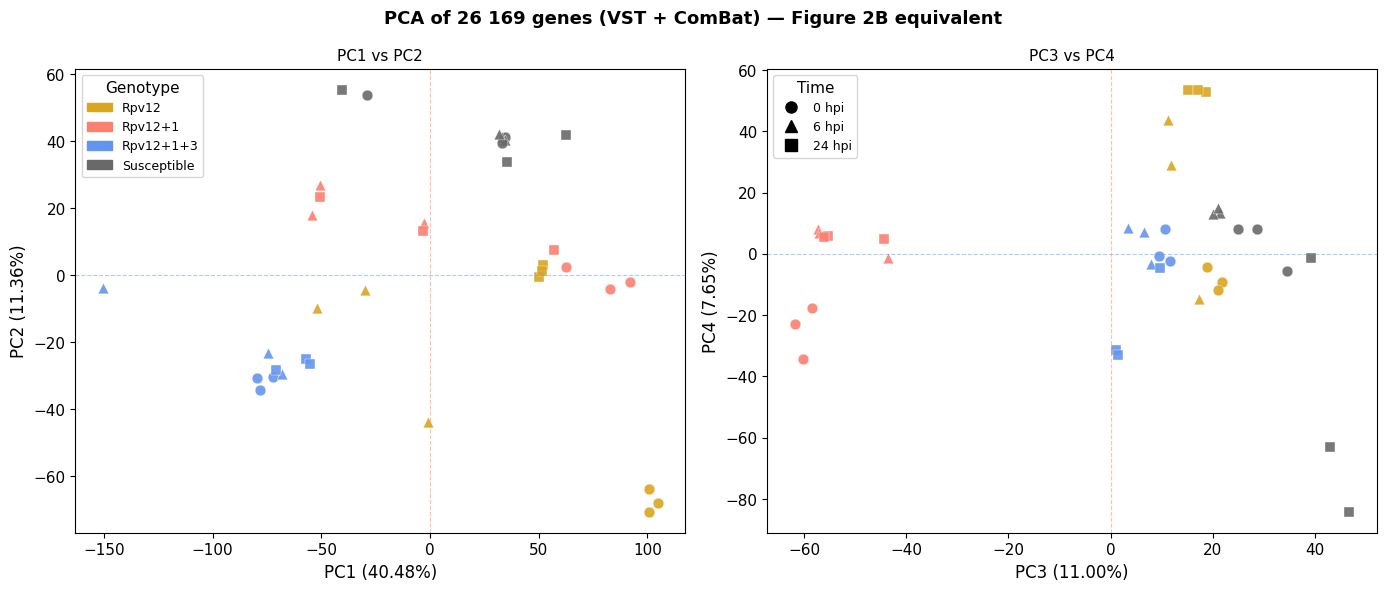

In [25]:
# ── PCA OF BATCH-CORRECTED EXPRESSION VALUES ──────────────────────────────────
# Reproduce Figure 2B from the paper: PCA of all 26 169 genes, VST + ComBat
# PC1 separates by genotype; PC2 separates by time

scores_vst, var_vst = run_pca(vst_combat, n_components=4)
ve = var_vst

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ["PC1 vs PC2", "PC3 vs PC4"]
pc_pairs = [(0, 1), (2, 3)]

for ax, (pc_x, pc_y), title in zip(axes, pc_pairs, titles):
    for i, sname in enumerate(sample_names):
        row = metadata.loc[sname]
        c  = genotype_color(row["genotype"])
        mk = TIME_MARKERS[row["time"]]
        ax.scatter(scores_vst[i, pc_x], scores_vst[i, pc_y],
                   color=c, marker=mk, s=60, alpha=0.9, edgecolors="white", lw=0.3)

    ax.set_xlabel(f"PC{pc_x+1} ({ve[pc_x]:.2f}%)", fontsize=12)
    ax.set_ylabel(f"PC{pc_y+1} ({ve[pc_y]:.2f}%)", fontsize=12)
    ax.axhline(0, lw=0.8, ls="--", color="cornflowerblue", alpha=0.5)
    ax.axvline(0, lw=0.8, ls="--", color="salmon", alpha=0.5)
    ax.set_title(title, fontsize=11)

# Legends
geno_handles = [mpatches.Patch(color=v, label=k) for k, v in GENOTYPE_COLORS.items()]
time_handles = [plt.Line2D([0],[0], marker=mk, color="black", linestyle="None",
                            markersize=8, label=f"{t} hpi") for t, mk in TIME_MARKERS.items()]
axes[0].legend(handles=geno_handles, title="Genotype", loc="upper left", fontsize=9)
axes[1].legend(handles=time_handles, title="Time",     loc="upper left", fontsize=9)

plt.suptitle("PCA of 26 169 genes (VST + ComBat) — Figure 2B equivalent",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Fig2B_PCA_genotype_time.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
# ── PC LOADING ANALYSIS: TOP 50 CONTRIBUTING GENES ──────────────────────────
# Genes driving each PC reveal the biological processes separating experimental groups.
# R equivalent: loadings <- BigPCA$rotation[,1:4]
#               contributions1 <- (squared_loadings[,1]/sum(squared_loadings[,1])) * 100

pca_full = PCA(n_components=4)
pca_full.fit(vst_combat.T.values)   # fit on samples × genes

# loadings: each column is a PC, each row is a gene's contribution
loadings = pd.DataFrame(
    pca_full.components_.T,     # genes × PCs
    index=vst_combat.index,
    columns=["PC1", "PC2", "PC3", "PC4"],
)
contributions = (loadings ** 2).div((loadings ** 2).sum(axis=0), axis=1) * 100

for pc in ["PC1", "PC2", "PC3", "PC4"]:
    top50 = contributions[pc].nlargest(50)
    pct_captured = top50.sum()
    print(f"{pc}: top 50 genes capture {pct_captured:.1f}% of variance in this PC")

print("\nTop 10 genes contributing to PC1 (paper: enriched for signaling, FDR=1.3e-10):")
print(contributions["PC1"].nlargest(10).to_string())


PC1: top 50 genes capture 7.7% of variance in this PC
PC2: top 50 genes capture 13.1% of variance in this PC
PC3: top 50 genes capture 12.8% of variance in this PC
PC4: top 50 genes capture 9.1% of variance in this PC

Top 10 genes contributing to PC1 (paper: enriched for signaling, FDR=1.3e-10):
geneID
Vitvi11g00518    0.289970
Vitvi10g00667    0.250997
Vitvi15g00714    0.231126
Vitvi04g00501    0.230049
Vitvi13g02005    0.217775
Vitvi08g00853    0.216230
Vitvi11g00708    0.208575
Vitvi09g00264    0.201745
Vitvi12g00456    0.191130
Vitvi07g01844    0.179543


## 7. Section 5 — Aggregated Expression Divergence (AED) <a name="sec5"></a>

> **Original R script:** `03_AED/analysis/comparison/scripts/DGE_bySFandCB_divergence.R`

### What is AED and why use it?

Standard differential expression analysis tests genes **individually** and reports a list of  
significant genes. But it cannot tell you: **how different is the overall transcriptome state**  
of a resistant genotype from the susceptible control?

**Aggregated Expression Divergence (AED)** is a global metric:

$$\text{AED} = \frac{1}{G} \sum_{g=1}^{G} (\bar{x}_{g,\text{resistant}} - \bar{x}_{g,\text{susceptible}})^2$$

where $G$ = number of genes, $\bar{x}$ = mean expression across replicates.

AED measures the **mean squared deviation** of a resistant genotype's transcriptome from the  
susceptible reference — across all genes simultaneously.

### Why size-factor + ComBat values (not VST)?

AED is sensitive to absolute expression **amplitude** (the magnitude of gene-level deviations).
VST (like rlog) shrinks large fold-changes (it's variance-stabilizing), which would compress
AED values and make large genuine differences look small. Size-factor normalization preserves
the amplitude, so large biological differences produce large AED contributions.

### Statistical testing via permutation

With only 3 replicates per condition, parametric tests have low power. Instead, we use a  
**permutation test**: under the null hypothesis (H₀) that the resistant genotype is no different  
from susceptible, any 3 samples from the same time-point are interchangeable.

There are $\binom{12}{3} = 220$ ways to choose 3 samples from 12 same-timepoint samples.  
We compute AED for all 220 random triplets vs the susceptible mean → null distribution.  
The **empirical p-value** = proportion of null AEDs ≥ observed AED.

The minimum attainable p-value is $1/220 = 0.0045$.  
After BH-FDR correction across 9 tests, the minimum attainable FDR = **0.024**.


In [ ]:
# ── LOAD SIZE-FACTOR + ComBat DATA ───────────────────────────────────────────
# This is the normalization chosen for AED: preserves fold-change amplitude
expr_aed = sf_combat.copy()   # genes × samples (pre-loaded earlier)
print(f"Expression matrix for AED: {expr_aed.shape}")

# Mean expression per condition group (for each genotype × time combination)
def group_mean(expr, col_indices):
    return expr.iloc[:, col_indices].mean(axis=1)

# Susceptible reference means per time point
mean_S0  = group_mean(expr_aed, COND_IDX["Susceptible.0"])
mean_S6  = group_mean(expr_aed, COND_IDX["Susceptible.6"])
mean_S24 = group_mean(expr_aed, COND_IDX["Susceptible.24"])

# Resistant genotype means
groups_by_time = {
    0: {
        "Rpv12":     group_mean(expr_aed, COND_IDX["Rpv12.0"]),
        "Rpv12+1":   group_mean(expr_aed, COND_IDX["Rpv12.1.0"]),
        "Rpv12+1+3": group_mean(expr_aed, COND_IDX["Rpv12.1.3.0"]),
    },
    6: {
        "Rpv12":     group_mean(expr_aed, COND_IDX["Rpv12.6"]),
        "Rpv12+1":   group_mean(expr_aed, COND_IDX["Rpv12.1.6"]),
        "Rpv12+1+3": group_mean(expr_aed, COND_IDX["Rpv12.1.3.6"]),
    },
    24: {
        "Rpv12":     group_mean(expr_aed, COND_IDX["Rpv12.24"]),
        "Rpv12+1":   group_mean(expr_aed, COND_IDX["Rpv12.1.24"]),
        "Rpv12+1+3": group_mean(expr_aed, COND_IDX["Rpv12.1.3.24"]),
    },
}
ref_means = {0: mean_S0, 6: mean_S6, 24: mean_S24}

# Compute AED for each genotype × time
def compute_aed(mean_resistant, mean_susceptible):
    """Mean squared gene-wise deviation (AED)."""
    return np.mean((mean_resistant - mean_susceptible) ** 2)

aed_obs = {}
for t, geno_dict in groups_by_time.items():
    for geno, mean_geno in geno_dict.items():
        aed_obs[(geno, t)] = compute_aed(mean_geno, ref_means[t])

print("Observed AED values:")
for (geno, t), aed in aed_obs.items():
    print(f"  {geno:12s} @ {t:2d} hpi : AED = {aed:.4f}")


In [ ]:
# ── PERMUTATION TEST: BUILD NULL DISTRIBUTIONS ────────────────────────────────
# For each time point, draw all C(12,3)=220 triplets from the 12 same-timepoint samples.
# Compute AED for each triplet vs the susceptible mean.
#
# R equivalent:
#   samples0 <- sample(seq(from=1, to=36, by=3))     # column indices of 0-hpi samples
#   combos0  <- combn(samples0, 3)                    # 3x220 matrix
#   AD_Ho_t0 <- sapply(1:220, function(i)
#       mean(abs(apply(expr_adj[, combos0[,i]], 1, mean) - mean_Go_0)^2))

import numpy as np
from itertools import combinations

np.random.seed(42)  # reproducibility

def null_aed_distribution(expr, all_time_col_indices, ref_mean):
    """
    Compute AED for all C(n,3) triplets chosen from all_time_col_indices.
    Returns array of 220 AED values forming the null distribution.
    """
    combos = list(combinations(all_time_col_indices, 3))
    assert len(combos) == 220, f"Expected 220, got {len(combos)}"
    null_aeds = []
    for triplet in combos:
        mean_triplet = expr.iloc[:, list(triplet)].mean(axis=1)
        null_aeds.append(compute_aed(mean_triplet, ref_mean))
    return np.array(null_aeds)

# All column indices for each time point (12 samples per time point)
time_col_indices = {
    0:  [i for i, s in enumerate(sample_names) if ".0." in s or s.endswith(".0.A") or
         metadata.loc[s, "time"] == 0],
    6:  [i for i, s in enumerate(sample_names) if metadata.loc[s, "time"] == 6],
    24: [i for i, s in enumerate(sample_names) if metadata.loc[s, "time"] == 24],
}
for t in [0, 6, 24]:
    time_col_indices[t] = [i for i, s in enumerate(sample_names)
                           if metadata.loc[s, "time"] == t]
    assert len(time_col_indices[t]) == 12, f"t={t}: {len(time_col_indices[t])} samples (expected 12)"

print("Building null distributions (220 combinations × 3 time points)...")
null_dists = {}
for t in [0, 6, 24]:
    null_dists[t] = null_aed_distribution(expr_aed, time_col_indices[t], ref_means[t])
    print(f"  t={t:2d} hpi: mean(null) = {null_dists[t].mean():.4f}  "
          f"max(null) = {null_dists[t].max():.4f}")


In [ ]:
# ── EMPIRICAL P-VALUES AND FDR ────────────────────────────────────────────────
# Empirical p-value = (# null AEDs >= observed AED + 1) / (220 + 1)
# The "+1" is a continuity correction that prevents p=0 (Lariviere & Langelier, 2001)
# R equivalent: p_emp <- (sum(AD_Ho_t0 >= AggrDiv_RPV12_0) + 1) / (length(AD_Ho_t0) + 1)

emp_pvals = {}
for (geno, t), obs_aed in aed_obs.items():
    null = null_dists[t]
    p = (np.sum(null >= obs_aed) + 1) / (len(null) + 1)
    emp_pvals[(geno, t)] = p

# Collect in the order: t=0 (3 genotypes), t=6, t=24
ordered_keys = [(g, t) for t in [0, 6, 24] for g in ["Rpv12", "Rpv12+1", "Rpv12+1+3"]]
p_array = [emp_pvals[k] for k in ordered_keys]

# BH-FDR correction across all 9 tests
_, fdr_array, _, _ = multipletests(p_array, method="fdr_bh")
fdr_dict = dict(zip(ordered_keys, fdr_array))

print("\nEmpirical p-values and FDR-corrected values:")
print(f"{'Genotype':12s} {'Time':5s} {'AED':8s} {'p_emp':8s} {'FDR':8s} {'Sig':4s}")
for k in ordered_keys:
    geno, t = k
    sig = "*" if fdr_dict[k] < 0.05 else ""
    print(f"{geno:12s} {t:3d}h   {aed_obs[k]:.4f}   {emp_pvals[k]:.4f}   {fdr_dict[k]:.4f}   {sig}")

print("\nExpected from paper:")
print("  Rpv12+1   @ 0 hpi : FDR=0.024*")
print("  Rpv12+1+3 @ 0 hpi : FDR=0.024*")
print("  Rpv12+1+3 @ 6 hpi : FDR=0.024*")
print("  Rpv12     @ 24 hpi: FDR=0.024*")
print("  Rpv12+1+3 @ 24 hpi: FDR=0.024*")


In [ ]:
# ── VISUALISATION: DENSITY PLOTS WITH OBSERVED AED VALUES ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
time_labels = ["0 hpi", "6 hpi", "24 hpi"]
geno_list   = ["Rpv12", "Rpv12+1", "Rpv12+1+3"]
geno_pch    = {0: "o", 6: "^", 24: "s"}

for ax, t, tlabel in zip(axes, [0, 6, 24], time_labels):
    null = null_dists[t]
    # KDE of null distribution
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(null)
    x_range = np.linspace(null.min() - 0.1, null.max() + 0.3, 300)
    ax.plot(x_range, kde(x_range), color="dimgray", lw=2, label="Null distribution")
    ax.fill_between(x_range, kde(x_range), alpha=0.15, color="dimgray")

    for geno in geno_list:
        obs = aed_obs[(geno, t)]
        c   = GENOTYPE_COLORS[geno]
        fdr = fdr_dict[(geno, t)]
        sig_label = f" (FDR={fdr:.3f}{'*' if fdr<0.05 else ''})"
        ax.axvline(obs, color=c, lw=2, label=f"{geno}{sig_label}")
        ax.scatter(obs, kde(obs), color=c, s=100, zorder=5)

    ax.set_title(tlabel, fontsize=13, fontweight="bold")
    ax.set_xlabel("AED (mean squared divergence)", fontsize=11)
    ax.set_ylabel("Density" if t == 0 else "", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Aggregated Expression Divergence — permutation test\n"
             "Vertical lines = observed AED per genotype; shaded = null distribution (220 combinations)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("Fig2A_AED_density_plots.png", dpi=150, bbox_inches="tight")
plt.show()


### Key findings from AED analysis

| Time | Significant genotypes (FDR < 0.05) |
|------|-------------------------------------|
| 0 hpi | *Rpv12+1*, *Rpv12+1+3* |
| 6 hpi | *Rpv12+1+3* only |
| 24 hpi | *Rpv12*, *Rpv12+1+3* |

**Interpretation:**
- *Rpv12* alone does not diverge significantly from susceptible at 0 hpi → no detectable pre-activation
- *Rpv12+1* and *Rpv12+1+3* show significant divergence at 0 hpi → altered basal transcriptional state
- Divergence is **not additive**: each genotype shows a different temporal trajectory
- The minimum attainable FDR (0.024) means borderline results (*Rpv12+1* at 24 hpi: FDR=0.068)  
  cannot be distinguished from true positives vs false negatives — requires quantitative resistance assays
